In [87]:
from read_model_runs import read_model_runs

question_long_df = read_model_runs('../data/processed/model-runs')

print('shape', question_long_df.shape)

question_long_df.head()

shape (4834, 20)


,model_name,firac,language,is_correct,pdf_filename,question_id,materia,prova,questao,enunciado,prompt,A,B,C,D,resposta_completa,alternativa,rule_count,correct,response_time_seconds
0,gemini-2.0-flash-lite,FIL__,portuguese,0,oab-26.pdf,oab-26.pdf-260,ÉTICA PROFISSIONAL,XXVII,260,"A advogada Mariana, gestante, ao ingressar em ...",Resolva a questão do exame da ordem da OAB aba...,Mariana tem o direito de não ser submetida a a...,Mariana tem o direito de não ser submetida a a...,"Mariana deverá, por medida de segurança, passa...","Mariana tem o direito, independentemente do te...",resposta: B\n,B,1.0,D,0.681947
1,gemini-2.0-flash-lite,FIL__,portuguese,1,oab-327.pdf,oab-327.pdf-055,PROCESSO DO TRABALHO,V,55,Com relação à competência material da Justiça ...,Resolva a questão do exame da ordem da OAB aba...,"não compete à Justiça do Trabalho, mas à Justi...",é da competência da Justiça do Trabalho o julg...,de acordo com o entendimento do Superior Tribu...,a Justiça do Trabalho é competente para julgar...,resposta: D\n,D,5.0,D,1.288225
2,gemini-2.0-flash-lite,FIL__,portuguese,0,oab-336.pdf,oab-336.pdf-151,PROCESSO DO TRABALHO,XXXI,151,Você foi contratado(a) para atuar nas seguinte...,Resolva a questão do exame da ordem da OAB aba...,Tanto na ação de cumprimento como na ação plúr...,O sindicato de classe da categoria poderá repr...,"Nas ações plúrima e de cumprimento, a parte au...",O sindicato da categoria poderá representar os...,resposta: D\n,D,6.0,C,1.319898
3,gemini-2.0-flash-lite,FIL__,portuguese,1,oab-95.pdf,oab-95.pdf-076,DIREITO INTERNACIONAL,XL,76,"Uma sociedade empresária colombiana celebrou, ...",Resolva a questão do exame da ordem da OAB aba...,"A autoridade judiciária inglesa, única e exclu...","A autoridade judiciária colombiana, concorrent...","A autoridade judiciária alemã, única e exclusi...","A autoridade judiciária brasileira, concorrent...",resposta: D\n,D,2.0,D,0.585031
4,gemini-2.0-flash-lite,FIL__,portuguese,1,oab-28.pdf,oab-28.pdf-275,ÉTICA PROFISSIONAL,XXIX,275,A Sociedade de Advogados X pretende associar-s...,Resolva a questão do exame da ordem da OAB aba...,"É autorizada, contudo deve haver formalização ...","É autorizada, contudo deve haver formalização ...","É autorizada, independentemente de averbação n...","Não é autorizada, pois os advogados João e Mar...",resposta: B\n,B,2.0,B,0.601043


Existe missing data?

In [88]:
question_long_df.isna().sum()


model_name               0
firac                    0
language                 0
is_correct               0
pdf_filename             0
question_id              0
materia                  0
prova                    0
questao                  0
enunciado                0
prompt                   0
A                        0
B                        0
C                        0
D                        0
resposta_completa        0
alternativa              7
rule_count               6
correct                  0
response_time_seconds    0
dtype: int64

In [89]:
question_long_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4834 entries, 0 to 4833
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   model_name             4834 non-null   object 
 1   firac                  4834 non-null   object 
 2   language               4834 non-null   object 
 3   is_correct             4834 non-null   int32  
 4   pdf_filename           4834 non-null   object 
 5   question_id            4834 non-null   object 
 6   materia                4834 non-null   object 
 7   prova                  4834 non-null   object 
 8   questao                4834 non-null   object 
 9   enunciado              4834 non-null   object 
 10  prompt                 4834 non-null   object 
 11  A                      4834 non-null   object 
 12  B                      4834 non-null   object 
 13  C                      4834 non-null   object 
 14  D                      4834 non-null   object 
 15  resp

In [90]:
# Mostra 'resposta_completa' quando 'alternativa' está vazia ou é NaN
question_long_df.loc[question_long_df['alternativa'].isna(), 'resposta_completa']


1875    A questão aborda os princípios da solidariedad...
1957    A questão aborda os institutos da solidariedad...
2002    A questão aborda a responsabilidade tributária...
2918    A resposta correta é B.\n\n**Justificativa:**\...
2921                                                  D\n
2929                                                 A: 3
4254                                          cevabı: C\n
Name: resposta_completa, dtype: object

In [91]:
import pandas as pd

# Supondo que question_long_df já está carregado

# Cálculo da acurácia média por modelo e por firac
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
model_accuracy["model_order"] = range(1, len(model_accuracy) + 1)

firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)
firac_accuracy["firac_order"] = range(1, len(firac_accuracy) + 1)

# Exibindo os resultados
print("Model order:")
print(model_accuracy)

print("\nFirac order:")
print(firac_accuracy)

model_order_accuracy = model_accuracy[["model_name"]].values
firac_order_accuracy = firac_accuracy[["firac"]].values




Model order:
                            model_name  is_correct  model_order
0                        gemma-3-1b-it    0.353952            1
1                        gemma-3-4b-it    0.586957            2
2                       gemma-3-27b-it    0.756039            3
3                       gemma-3-12b-it    0.768116            4
4                gemini-2.5-flash-lite    0.795660            5
5  gemini-2.5-flash-lite-preview-06-17    0.805054            6
6                gemini-2.0-flash-lite    0.820000            7
7                     gemini-2.0-flash    0.832130            8
8                     gemini-2.5-flash    0.941509            9
9                       gemini-2.5-pro    0.978571           10

Firac order:
   firac  is_correct  firac_order
0   ____    0.655536            1
1  F____    0.657941            2
2  __L__    0.663755            3
3  FI___    0.708621            4
4  FIL__    0.720000            5
5  __R__    0.836601            6
6  FIR__    0.917127           

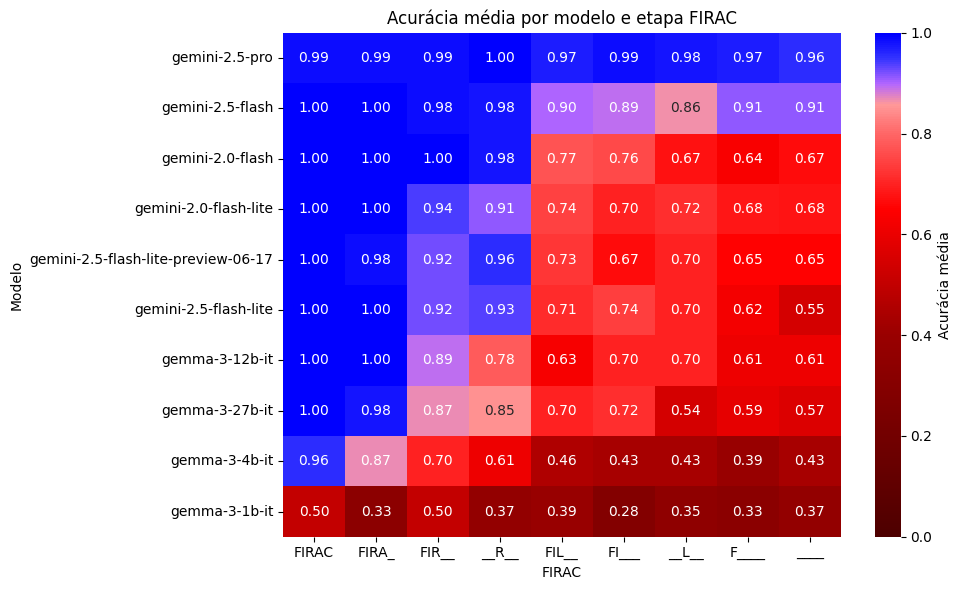

In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Calcular acurácia média por modelo e firac
heatmap_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .unstack()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Reordenar DataFrame
heatmap_data = heatmap_data.loc[model_order_accuracy, firac_order_accuracy]

# 4. Colormap com nuances vermelhas e transição suave após 0.9
custom_cmap = LinearSegmentedColormap.from_list(
    "detailed_red_blue",
    [
        (0.0, "#4d0000"),   # 0.00 = vermelho muito escuro
        (0.4, "#990000"),   # 0.40 = vermelho forte
        (0.65, "#ff0000"),  # 0.65 = vermelho puro
        (0.80, "#ff6666"),  # 0.80 = vermelho claro
        (0.86, "#ff9999"),  # 0.86 = rosado
        (0.90, "#b366ff"),  # 0.90 = começa roxo
        (0.95, "#3333ff"),  # 0.95 = azul forte
        (1.0, "blue")       # 1.00 = azul puro
    ]
)

# 5. Plotar o heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Acurácia média'}
)
plt.title("Acurácia média por modelo e etapa FIRAC")
plt.xlabel("FIRAC")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()


In [93]:
!pip install adjustText


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: C:\Users\pedro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


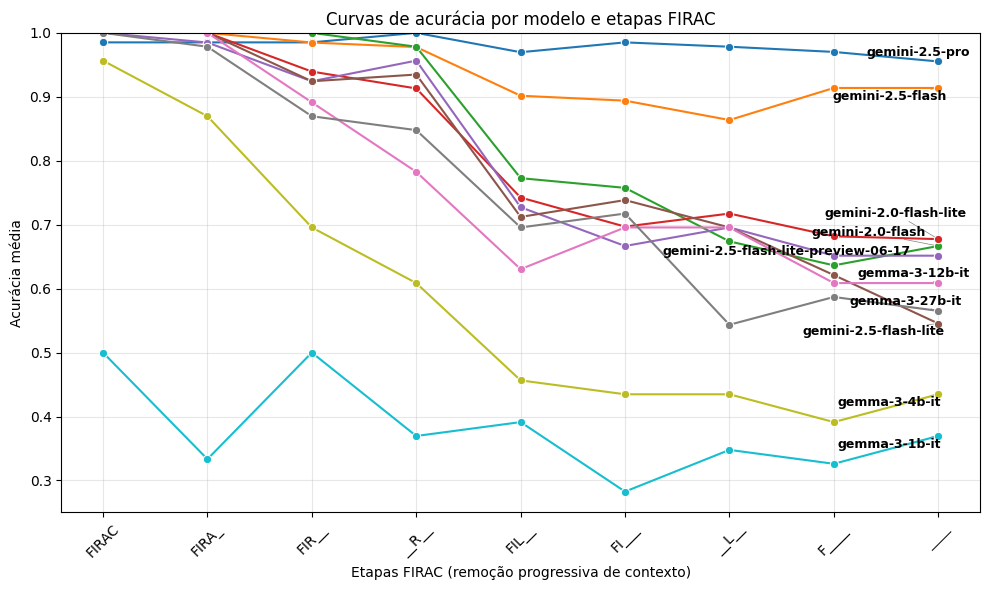

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Calcular acurácia média por modelo e firac
curve_data = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .reset_index()
)

# 2. Calcular ordem dos modelos e FIRAC
model_accuracy = (
    question_long_df.groupby("model_name")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)
firac_accuracy = (
    question_long_df.groupby("firac")["is_correct"]
    .mean()
    .sort_values(ascending=False)
)

model_order_accuracy = model_accuracy.index.tolist()
firac_order_accuracy = firac_accuracy.index.tolist()

# 3. Garantir que as colunas sejam categóricas e ordenadas
curve_data["firac"] = pd.Categorical(
    curve_data["firac"], 
    categories=firac_order_accuracy, 
    ordered=True
)
curve_data["model_name"] = pd.Categorical(
    curve_data["model_name"], 
    categories=model_order_accuracy, 
    ordered=True
)

# 4. Plotar as curvas sem legenda
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=curve_data,
    x="firac",
    y="is_correct",
    hue="model_name",
    hue_order=model_order_accuracy,
    marker="o",
    legend=False
)

# 5. Adicionar labels perto das curvas
texts = []
for model in curve_data["model_name"].unique():
    subset = curve_data[curve_data["model_name"] == model]
    last_x = subset["firac"].iloc[-1]
    last_y = subset["is_correct"].iloc[-1]
    texts.append(
        plt.text(
            x=len(firac_order_accuracy) - 1,  # posição no eixo x
            y=last_y,
            s=model,
            fontsize=9,
            fontweight="bold"
        )
    )

# Ajustar automaticamente para evitar sobreposição
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

# 6. Estilização
plt.title("Curvas de acurácia por modelo e etapas FIRAC")
plt.xlabel("Etapas FIRAC (remoção progressiva de contexto)")
plt.ylabel("Acurácia média")
plt.ylim(0.25, 1)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# -----------------------
# 1. Transformar para wide format
# -----------------------
curve_wide = curve_data.pivot(index="question_id", columns="firac", values="is_correct").fillna(0)

# -----------------------
# 2. Clusterizar as curvas semelhantes
# -----------------------
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(curve_wide)

curve_data = curve_data.merge(
    pd.DataFrame({"question_id": curve_wide.index, "cluster": clusters}),
    on="question_id"
)

# -----------------------
# 3. Reordenar os clusters com base na média de is_correct
# -----------------------
cluster_means = (
    curve_data.groupby("cluster")["is_correct"]
    .mean()
    .sort_values()
    .reset_index()
)
cluster_order = {old: new for new, old in enumerate(cluster_means["cluster"])}
curve_data["cluster"] = curve_data["cluster"].map(cluster_order)

# -----------------------
# 4. Função para plotar curvas individuais + média
# -----------------------
def plot_cluster_data(data, **kwargs):
    sns.lineplot(
        data=data,
        x="firac", y="is_correct",
        hue="question_id",
        alpha=0.4, lw=1, legend=False
    )
    mean_curve = data.groupby("firac")["is_correct"].mean().reset_index()
    sns.lineplot(
        data=mean_curve,
        x="firac", y="is_correct",
        color="black", lw=3
    )

# -----------------------
# 5. Visualizar clusters individualmente (FacetGrid)
# -----------------------
g = sns.FacetGrid(
    curve_data,
    col="cluster",
    col_wrap=3,
    height=3,
    sharey=True
)
g.map_dataframe(plot_cluster_data)
g.set_titles("Cluster {col_name}")

# Rotacionar labels do eixo X
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# -----------------------
# 6. Novo gráfico: curvas médias dos 3 clusters com erro padrão
# -----------------------

# Calcular média e erro padrão por cluster e firac
summary = (
    curve_data.groupby(["cluster", "firac"])["is_correct"]
    .agg(["mean", "sem"])  # sem = standard error of the mean
    .reset_index()
)

# Plotar todas as curvas juntas
plt.figure(figsize=(7, 5))
sns.lineplot(
    data=summary,
    x="firac", y="mean",
    hue="cluster",
    linewidth=2.5,
    err_style="band",
    err_kws={"alpha": 0.2},
)

# Adicionar bandas de erro manualmente (para mais controle visual)
for cluster_id, cluster_df in summary.groupby("cluster"):
    plt.fill_between(
        cluster_df["firac"],
        cluster_df["mean"] - cluster_df["sem"],
        cluster_df["mean"] + cluster_df["sem"],
        alpha=0.2
    )

plt.title("Clusters de questões por perfil cognitivo")
plt.xlabel("FIRAC")
plt.ylabel("Acurácia")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


KeyError: 'question_id'

In [ ]:
# 1. Calcular acurácia média por combinação model_name + firac
accuracy_order = (
    question_long_df
    .groupby(["model_name", "firac"])["is_correct"]
    .mean()
    .sort_values(ascending=True)
)

# 2. Pivotar para o formato wide
question_wide_df = (
    question_long_df
    .pivot_table(
        index="question_id",
        columns=["model_name", "firac"],
        values="is_correct"
    )
)

# 3. Reordenar as colunas conforme a acurácia calculada
question_wide_df = question_wide_df[accuracy_order.index]

# 4. Flatten do MultiIndex nas colunas
question_wide_df.columns = [
    f"{model}_{firac}" for model, firac in question_wide_df.columns
]

# 5. Resetar o índice (opcional)
question_wide_df = question_wide_df.reset_index()

#question_wide_df = question_wide_df.dropna(axis=1, how="any")

question_wide_df.head()


,question_id,gemma-3-1b-it_FI___,gemma-3-1b-it_F____,gemma-3-1b-it_FIRA_,gemma-3-1b-it___L__,gemma-3-1b-it___R__,gemma-3-1b-it_____,gemma-3-1b-it_FIL__,gemma-3-4b-it_F____,gemma-3-4b-it_____,gemma-3-4b-it_FI___,gemma-3-4b-it___L__,gemma-3-4b-it_FIL__,gemma-3-1b-it_FIR__,gemma-3-1b-it_FIRAC,gemma-3-27b-it___L__,gemini-2.5-flash-lite_____,gemma-3-27b-it_____,gemma-3-27b-it_F____,gemma-3-12b-it_____,gemma-3-12b-it_F____,gemma-3-4b-it___R__,gemini-2.5-flash-lite_F____,gemma-3-12b-it_FIL__,gemini-2.0-flash_F____,gemini-2.5-flash-lite-preview-06-17_F____,gemini-2.5-flash-lite-preview-06-17_____,gemini-2.0-flash_____,gemini-2.5-flash-lite-preview-06-17_FI___,gemini-2.0-flash___L__,gemini-2.0-flash-lite_____,gemini-2.0-flash-lite_F____,gemma-3-12b-it_FI___,gemma-3-4b-it_FIR__,gemini-2.5-flash-lite___L__,gemini-2.5-flash-lite-preview-06-17___L__,gemma-3-27b-it_FIL__,gemma-3-12b-it___L__,gemini-2.0-flash-lite_FI___,gemini-2.5-flash-lite_FIL__,gemini-2.0-flash-lite___L__,gemma-3-27b-it_FI___,gemini-2.5-flash-lite-preview-06-17_FIL__,gemini-2.5-flash-lite_FI___,gemini-2.0-flash-lite_FIL__,gemini-2.0-flash_FI___,gemini-2.0-flash_FIL__,gemma-3-12b-it___R__,gemma-3-27b-it___R__,gemini-2.5-flash___L__,gemma-3-4b-it_FIRA_,gemma-3-27b-it_FIR__,gemma-3-12b-it_FIR__,gemini-2.5-flash_FI___,gemini-2.5-flash_FIL__,gemini-2.0-flash-lite___R__,gemini-2.5-flash_____,gemini-2.5-flash_F____,gemini-2.5-flash-lite_FIR__,gemini-2.5-flash-lite-preview-06-17_FIR__,gemini-2.5-flash-lite___R__,gemini-2.0-flash-lite_FIR__,gemini-2.5-pro_____,gemma-3-4b-it_FIRAC,gemini-2.5-flash-lite-preview-06-17___R__,gemini-2.5-pro_FIL__,gemini-2.5-pro_F____,gemini-2.5-flash___R__,gemini-2.0-flash___R__,gemma-3-27b-it_FIRA_,gemini-2.5-pro___L__,gemini-2.5-flash_FIR__,gemini-2.5-flash-lite-preview-06-17_FIRA_,gemini-2.5-pro_FIRAC,gemini-2.5-pro_FIRA_,gemini-2.5-pro_FIR__,gemini-2.5-pro_FI___,gemini-2.5-flash-lite_FIRAC,gemini-2.0-flash_FIRA_,gemini-2.0-flash_FIR__,gemini-2.0-flash_FIRAC,gemini-2.5-flash-lite_FIRA_,gemini-2.5-pro___R__,gemma-3-27b-it_FIRAC,gemini-2.0-flash-lite_FIRA_,gemini-2.5-flash_FIRAC,gemma-3-12b-it_FIRA_,gemma-3-12b-it_FIRAC,gemini-2.5-flash_FIRA_,gemini-2.5-flash-lite-preview-06-17_FIRAC,gemini-2.0-flash-lite_FIRAC
0,oab-10.pdf-094,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,NaN,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,oab-110.pdf-118,0.0,0.0,NaN,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,oab-112.pdf-140,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.5,0.5,0.0,0.5,0.0,1.0,0.0,0.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,oab-115.pdf-168,0.0,1.0,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,1.0,1.0,1.0,0.0,0.0,1.0,0.0,NaN,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,oab-13.pdf-123,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,NaN,NaN,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.

In [ ]:
pd.set_option('display.max_rows', None)


# Conta o número de valores NaN por coluna
na_counts = question_wide_df.isna().sum()

# Mostra o resultado ordenado do maior para o menor
na_counts.sort_values(ascending=False)

gemma-3-1b-it_FIRA_                          44
gemma-3-1b-it_FIRAC                          43
gemma-3-1b-it_FIR__                          39
gemini-2.5-flash_____                         6
gemini-2.5-flash___L__                        3
gemini-2.5-flash-lite_FI___                   2
gemini-2.5-flash_F____                        2
gemini-2.5-flash___R__                        2
gemma-3-27b-it_FIR__                          1
gemma-3-12b-it_FIR__                          1
gemini-2.5-flash_FI___                        1
gemini-2.5-flash_FIL__                        1
gemini-2.5-pro_FIL__                          1
gemma-3-4b-it_FIRA_                           1
gemma-3-27b-it___R__                          1
gemma-3-12b-it___R__                          1
gemini-2.0-flash_FIL__                        1
gemini-2.5-flash-lite_FIR__                   1
gemini-2.5-flash-lite-preview-06-17_FIR__     1
gemini-2.5-flash-lite___R__                   1
gemini-2.0-flash-lite_FIR__             

In [ ]:
# Mantém apenas as colunas que começam com 'gemini'
question_wide_df = question_wide_df.filter(regex=r'^gemini')

# Verifica o resultado
question_wide_df.head()
question_wide_df = question_wide_df.dropna()

question_wide_df.head()

,gemini-2.5-flash-lite_____,gemini-2.5-flash-lite_F____,gemini-2.0-flash_F____,gemini-2.5-flash-lite-preview-06-17_F____,gemini-2.5-flash-lite-preview-06-17_____,gemini-2.0-flash_____,gemini-2.5-flash-lite-preview-06-17_FI___,gemini-2.0-flash___L__,gemini-2.0-flash-lite_____,gemini-2.0-flash-lite_F____,gemini-2.5-flash-lite___L__,gemini-2.5-flash-lite-preview-06-17___L__,gemini-2.0-flash-lite_FI___,gemini-2.5-flash-lite_FIL__,gemini-2.0-flash-lite___L__,gemini-2.5-flash-lite-preview-06-17_FIL__,gemini-2.5-flash-lite_FI___,gemini-2.0-flash-lite_FIL__,gemini-2.0-flash_FI___,gemini-2.0-flash_FIL__,gemini-2.5-flash___L__,gemini-2.5-flash_FI___,gemini-2.5-flash_FIL__,gemini-2.0-flash-lite___R__,gemini-2.5-flash_____,gemini-2.5-flash_F____,gemini-2.5-flash-lite_FIR__,gemini-2.5-flash-lite-preview-06-17_FIR__,gemini-2.5-flash-lite___R__,gemini-2.0-flash-lite_FIR__,gemini-2.5-pro_____,gemini-2.5-flash-lite-preview-06-17___R__,gemini-2.5-pro_FIL__,gemini-2.5-pro_F____,gemini-2.5-flash___R__,gemini-2.0-flash___R__,gemini-2.5-pro___L__,gemini-2.5-flash_FIR__,gemini-2.5-flash-lite-preview-06-17_FIRA_,gemini-2.5-pro_FIRAC,gemini-2.5-pro_FIRA_,gemini-2.5-pro_FIR__,gemini-2.5-pro_FI___,gemini-2.5-flash-lite_FIRAC,gemini-2.0-flash_FIRA_,gemini-2.0-flash_FIR__,gemini-2.0-flash_FIRAC,gemini-2.5-flash-lite_FIRA_,gemini-2.5-pro___R__,gemini-2.0-flash-lite_FIRA_,gemini-2.5-flash_FIRAC,gemini-2.5-flash_FIRA_,gemini-2.5-flash-lite-preview-06-17_FIRAC,gemini-2.0-flash-lite_FIRAC
1,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.0,0.0,0.5,0.5,0.0,0.5,0.0,1.0,0.0,0.5,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

pd.set_option('display.max_columns', None)


# 1. Separar apenas as colunas numéricas
X = question_wide_df.select_dtypes(include="number")

# 2. Definir o número de clusters
n_clusters = 2

# 3. Rodar o K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
question_wide_df["cluster"] = kmeans.fit_predict(X)

# 4. Criar um DataFrame dos centróides
cluster_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns,
    index=[f"Cluster {i}" for i in range(n_clusters)]
)

# 5. Adicionar uma coluna com o tamanho de cada cluster
cluster_sizes = question_wide_df["cluster"].value_counts().sort_index()
cluster_df["size"] = cluster_sizes.values

# 6. Mostrar o resultado arredondado para melhor visualização
cluster_df = cluster_df.round(3)
cluster_df.head()


,gemini-2.5-flash-lite_____,gemini-2.5-flash-lite_F____,gemini-2.0-flash_F____,gemini-2.5-flash-lite-preview-06-17_F____,gemini-2.5-flash-lite-preview-06-17_____,gemini-2.0-flash_____,gemini-2.5-flash-lite-preview-06-17_FI___,gemini-2.0-flash___L__,gemini-2.0-flash-lite_____,gemini-2.0-flash-lite_F____,gemini-2.5-flash-lite___L__,gemini-2.5-flash-lite-preview-06-17___L__,gemini-2.0-flash-lite_FI___,gemini-2.5-flash-lite_FIL__,gemini-2.0-flash-lite___L__,gemini-2.5-flash-lite-preview-06-17_FIL__,gemini-2.5-flash-lite_FI___,gemini-2.0-flash-lite_FIL__,gemini-2.0-flash_FI___,gemini-2.0-flash_FIL__,gemini-2.5-flash___L__,gemini-2.5-flash_FI___,gemini-2.5-flash_FIL__,gemini-2.0-flash-lite___R__,gemini-2.5-flash_____,gemini-2.5-flash_F____,gemini-2.5-flash-lite_FIR__,gemini-2.5-flash-lite-preview-06-17_FIR__,gemini-2.5-flash-lite___R__,gemini-2.0-flash-lite_FIR__,gemini-2.5-pro_____,gemini-2.5-flash-lite-preview-06-17___R__,gemini-2.5-pro_FIL__,gemini-2.5-pro_F____,gemini-2.5-flash___R__,gemini-2.0-flash___R__,gemini-2.5-pro___L__,gemini-2.5-flash_FIR__,gemini-2.5-flash-lite-preview-06-17_FIRA_,gemini-2.5-pro_FIRAC,gemini-2.5-pro_FIRA_,gemini-2.5-pro_FIR__,gemini-2.5-pro_FI___,gemini-2.5-flash-lite_FIRAC,gemini-2.0-flash_FIRA_,gemini-2.0-flash_FIR__,gemini-2.0-flash_FIRAC,gemini-2.5-flash-lite_FIRA_,gemini-2.5-pro___R__,gemini-2.0-flash-lite_FIRA_,gemini-2.5-flash_FIRAC,gemini-2.5-flash_FIRA_,gemini-2.5-flash-lite-preview-06-17_FIRAC,gemini-2.0-flash-lite_FIRAC,size
Cluster 0,0.672,0.776,0.793,0.793,0.862,0.776,0.914,0.828,0.845,0.845,0.897,0.862,0.931,0.862,0.862,0.948,0.914,0.983,0.966,0.948,0.897,0.931,0.966,0.966,0.966,0.914,0.983,0.983,1.00,1.00,1.0,0.966,1.0,1.0,1.000,1.000,1.0,1.0,0.966,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,29
Cluster 1,0.125,0.062,0.125,0.250,0.000,0.312,0.000,0.250,0.188,0.188,0.250,0.125,0.063,0.188,0.250,0.250,0.250,0.062,0.125,0.125,1.000,0.875,0.812,0.750,0.812,0.938,0.812,0.688,0.75,0.75,1.0,0.875,1.0,1.0,0.875,0.875,1.0,1.0,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,8
